In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
import numpy as np
from collections import Counter

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf_node(self):
        return self.value is not None

class DecisionTree:
    def __init__(self, min_samples_split=2, max_depth=100, n_features=None):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.n_features = n_features
        self.root = None

    def fit(self, X, y):
        self.n_features = X.shape[1] if not self.n_features else min(X.shape[1], self.n_features)
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_feats = X.shape
        n_labels = len(np.unique(y))

       
        if (depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split):
            leaf_value = self._calculate_leaf_value(y) 
            return Node(value=leaf_value)

        feat_idxs = np.random.choice(n_feats, self.n_features, replace=False)
        best_feature, best_thresh = self._best_split(X, y, feat_idxs)

        left_idxs, right_idxs = self._split(X[:, best_feature], best_thresh)
        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth+1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth+1)
        return Node(best_feature, best_thresh, left, right)

    def _best_split(self, X, y, feat_idxs):
        best_gain = -1
        split_idx, split_threshold = None, None

        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)

            for threshold in thresholds:
                
                gain = self._variance_reduction(y, X_column, threshold)

                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_threshold = threshold

        return split_idx, split_threshold

    def _variance_reduction(self, y, X_column, threshold):
       
        parent_var = self._variance(y)

        left_idxs, right_idxs = self._split(X_column, threshold)
        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0

        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        e_l, e_r = self._variance(y[left_idxs]), self._variance(y[right_idxs])

        child_var = (n_l/n) * e_l + (n_r/n) * e_r
        return parent_var - child_var

    def _split(self, X_column, split_thresh):
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs

    def _variance(self, y):
        if len(y) == 0: return 0
        return np.var(y)

    def _calculate_leaf_value(self, y):
        return np.mean(y)

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value 
        
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

class RandomForest:
    def __init__(self, n_trees=100, max_depth=10, min_samples_split=2, n_features=None):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split 
        self.n_features = n_features
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        for _ in range(self.n_trees):
          
            tree = DecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                n_features=self.n_features
            )
            X_sample, y_sample = self._bootstrap_samples(X, y)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def _bootstrap_samples(self, X, y):
        n_samples = X.shape[0]
        idxs = np.random.choice(n_samples, n_samples, replace=True)
        return X[idxs], y[idxs]

    def predict(self, X):
        predictions = np.array([tree.predict(X) for tree in self.trees])
        return np.mean(predictions, axis=0)

In [3]:
#Declaration of the dataset
df = pd.read_csv(r"C:\Users\touze\Desktop\machine learning projects\ml project #3 - diamond price prediction\diamonds.csv",sep=';', 
                     low_memory=False)
cut_mapping = {'Fair': 0, 'Good': 1, 'Very Good': 2, 'Premium': 3, 'Ideal': 4}
df['cut'] = df['cut'].map(cut_mapping)

color_mapping = {'J': 0, 'I': 1, 'H': 2, 'G': 3, 'F': 4, 'E': 5, 'D': 6}
df['color'] = df['color'].map(color_mapping)

clarity_mapping = {'I1': 0, 'SI2': 1, 'SI1': 2, 'VS2': 3, 'VS1': 4, 'VVS2': 5, 'VVS1': 6, 'IF': 7}
df['clarity'] = df['clarity'].map(clarity_mapping)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  int64  
 2   color    53940 non-null  int64  
 3   clarity  53940 non-null  int64  
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   x        53940 non-null  float64
 7   y        53940 non-null  float64
 8   z        53940 non-null  float64
 9   price    53940 non-null  int64  
dtypes: float64(6), int64(4)
memory usage: 4.1 MB
None


In [4]:
print(f"Taille avant dédoublonnage : {len(df)}")
df = df.drop_duplicates()
print(f"Taille après dédoublonnage : {len(df)}")

Taille avant dédoublonnage : 53940
Taille après dédoublonnage : 53794


In [5]:
#Dataset inspection

print("Dataset structure:")
print(f"Shape : {df.shape}")
print("      ")
print(f"Data types:")
print(df.dtypes.value_counts())

Dataset structure:
Shape : (53794, 10)
      
Data types:
float64    6
int64      4
Name: count, dtype: int64


In [104]:
#Data cleaning

df_clean = df.copy()

columns_to_convert = ['carat', 'depth', 'table', 'x', 'y', 'z', 'price']

for col in columns_to_convert:
     df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
     print(f"Column converted: {col}")


print(f"\nFinal structure:")
print(df_clean.dtypes.value_counts())

Column converted: carat
Column converted: depth
Column converted: table
Column converted: x
Column converted: y
Column converted: z
Column converted: price

Final structure:
float64    6
int64      4
Name: count, dtype: int64


In [105]:
print(df_clean.head())

   carat  cut  color  clarity  depth  table     x     y     z  price
0   0.23    4      5        1   61.5   55.0  3.95  3.98  2.43    326
1   0.21    3      5        2   59.8   61.0  3.89  3.84  2.31    326
2   0.23    1      5        4   56.9   65.0  4.05  4.07  2.31    327
3   0.29    3      1        3   62.4   58.0  4.20  4.23  2.63    334
4   0.31    1      0        1   63.3   58.0  4.34  4.35  2.75    335


In [106]:
#Dataset division between intput and ouput sections

X = df_clean.drop(columns=['price'])
print(X.head())

   carat  cut  color  clarity  depth  table     x     y     z
0   0.23    4      5        1   61.5   55.0  3.95  3.98  2.43
1   0.21    3      5        2   59.8   61.0  3.89  3.84  2.31
2   0.23    1      5        4   56.9   65.0  4.05  4.07  2.31
3   0.29    3      1        3   62.4   58.0  4.20  4.23  2.63
4   0.31    1      0        1   63.3   58.0  4.34  4.35  2.75


In [107]:
y = df_clean['price']
print(y.head())

0    326
1    326
2    327
3    334
4    335
Name: price, dtype: int64


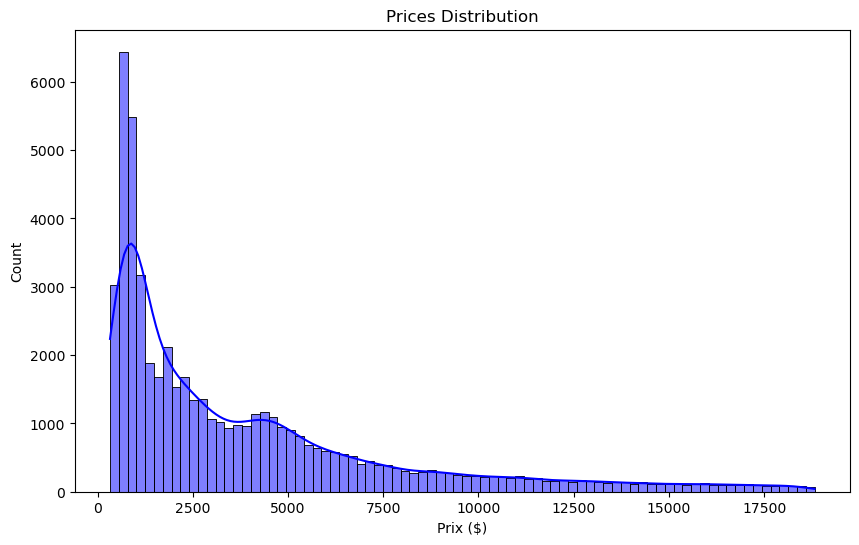

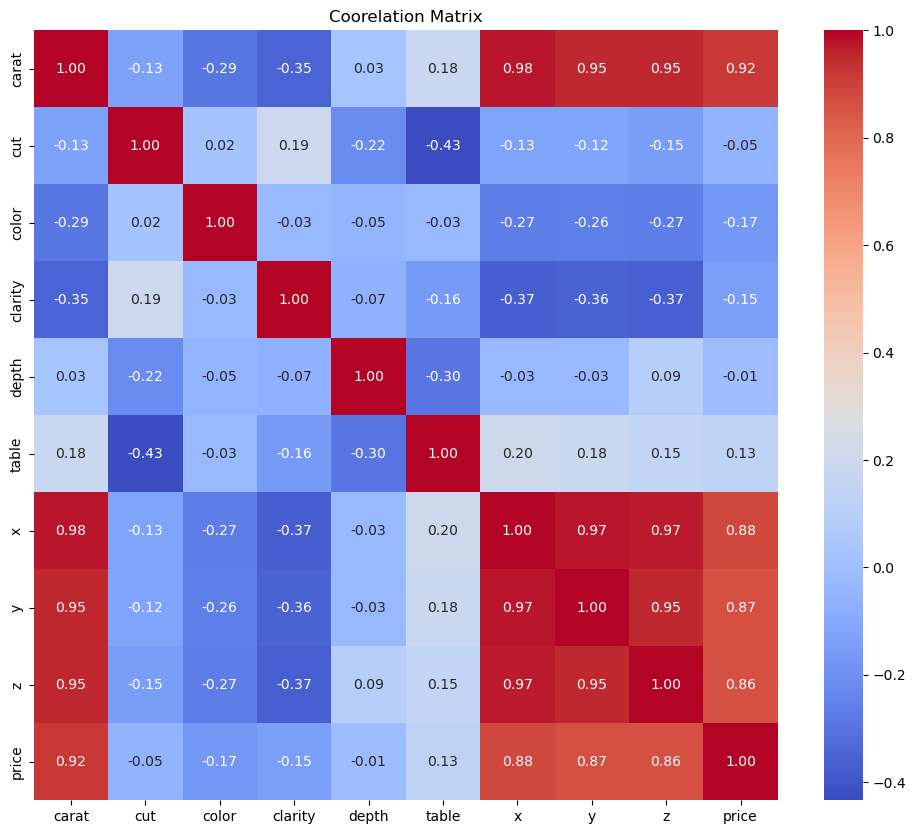

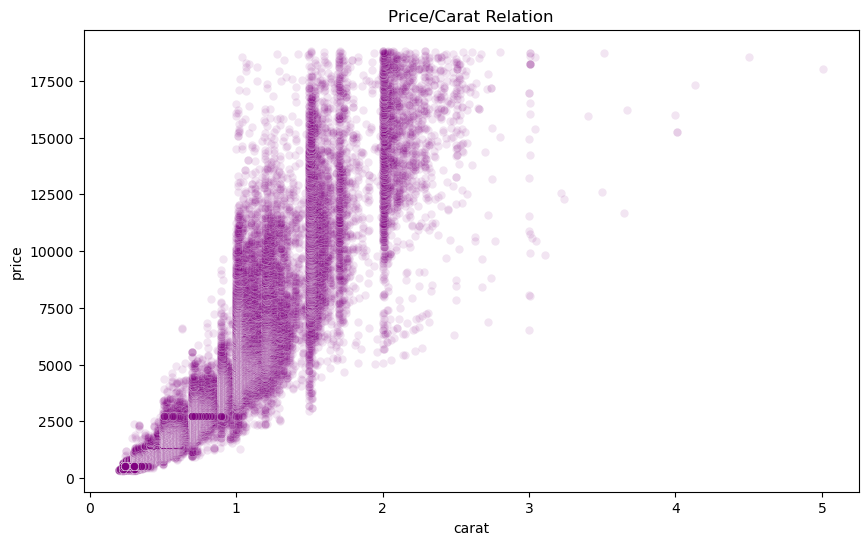

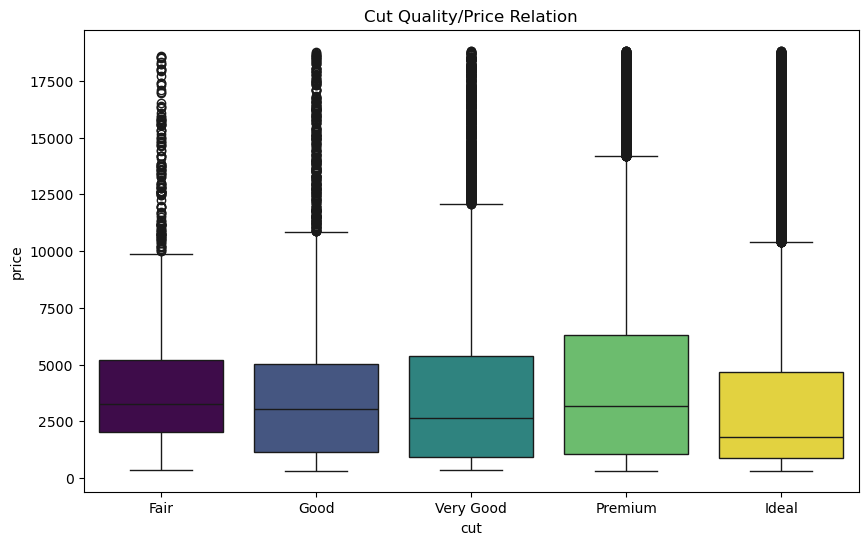

In [112]:
#Data Visualization
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, color='blue')
plt.title("Prices Distribution")
plt.xlabel("Prix ($)")
plt.show()

plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=['number']) 
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Coorelation Matrix")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='carat', y='price', alpha=0.1, color='purple')
plt.title("Price/Carat Relation")
plt.show()


plt.figure(figsize=(10, 6))

numeric_order = [0, 1, 2, 3, 4]
labels = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']


sns.boxplot(data=df, x='cut', y='price', order=numeric_order, hue='cut', palette='viridis', legend=False)
plt.xticks(ticks=numeric_order, labels=labels)

plt.title("Cut Quality/Price Relation")
plt.show()

In [108]:
#Definition and training of the model

model = RandomForest(n_trees=10, max_depth=6, min_samples_split=4)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state =42)
np.random.seed(42)
y_train_log = np.log(y_train) 
model.fit(X_train.values, y_train_log.values)
predictions_log = model.predict(X_test.values)
predictions = np.exp(predictions_log)

In [109]:
#Performance analysis

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"mean error: {rmse:.2f} $")
print(f"absolute mean error: {mae:.2f} $")
print(f"R2:{r2:.4f}")

mean error: 895.13 $
absolute mean error: 486.83 $
R2:0.9496


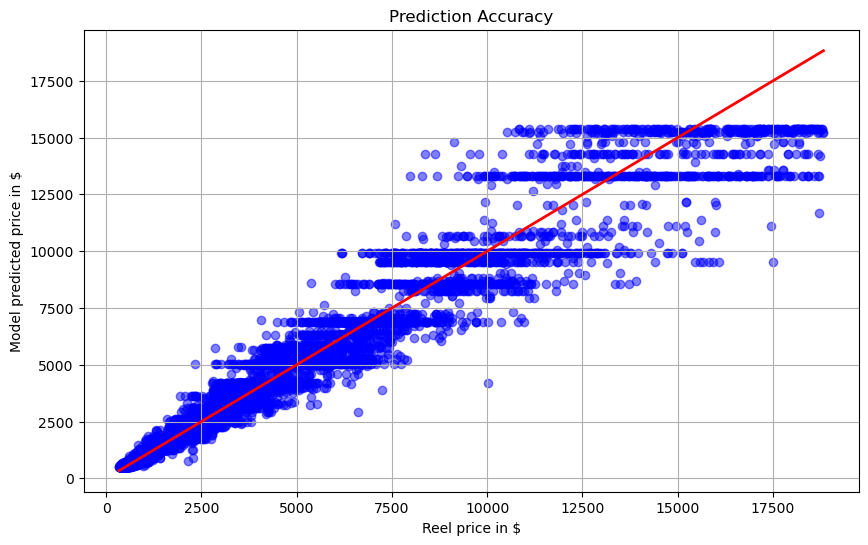

In [110]:
#Performance Visualization

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.5, color='blue')


plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)

plt.xlabel("Reel price in $")
plt.ylabel("Model predicted price in $")
plt.title("Prediction Accuracy")
plt.grid(True)
plt.show()